# 🧠 Person Detection: HOG + LinearSVM — Train 2 Dataset
**Pipeline:** Dataset 1 → Train SVM → Lấy model tốt nhất → Dataset 2 → Fine-tune → Test

---
### Luồng train:
```
DATASET 1 ──► Load + Augment ──► HOG ──► CV ──► Train ──► Best Model 1
                                                                  │
DATASET 2 ──► Load + Augment ──► HOG ──►      Fine-tune ──► Best Model 2
                                                                  │
TEST SET  ──────────────────────────────────────────────► Evaluate & Export
```

## 📦 Bước 1: Cài đặt thư viện

In [ ]:
!pip install scikit-learn scikit-image opencv-python-headless imbalanced-learn joblib tqdm matplotlib seaborn -q
print('✅ Cài đặt xong!')

✅ Cài đặt xong!


## 🔗 Bước 2: Kết nối Google Drive

In [ ]:
import subprocess, os, shutil
from google.colab import drive

subprocess.run(['fusermount', '-uz', '/content/drive'], capture_output=True)
if os.path.exists('/content/drive'):
    try:
        shutil.rmtree('/content/drive', ignore_errors=True)
    except:
        pass

drive.mount('/content/drive')

if os.path.exists('/content/drive/MyDrive'):
    items = os.listdir('/content/drive/MyDrive')
    print(f'✅ Drive đã kết nối! Có {len(items)} items trong MyDrive')
    folders = [x for x in sorted(items) if os.path.isdir(f'/content/drive/MyDrive/{x}')]
    print('📁 Thư mục:', folders)
else:
    print('❌ Mount thất bại!')

Mounted at /content/drive
✅ Drive đã kết nối! Có 58 items trong MyDrive
📁 Thư mục: ['.ipynb_checkpoints', 'AI', 'ANN_based_classification_nhom8', 'AdviceModel_Distillation', 'AdviceModel_Distillation (1)', 'Colab Notebooks', 'DL', 'EmotionAdviceAI', 'TTNT_CK', 'TrainAI', 'TrainAI1', 'cityscapes_data', 'models', 'models (1)', 'person_model', 'person_model (1)']


## ⚙️ Bước 3: Cấu hình đường dẫn — CHỈNH SỬA Ở ĐÂY

In [ ]:
import os, glob

# ================================================================
# 🔧 CHỈNH SỬA 3 ĐƯỜNG DẪN NÀY
# ================================================================

# Tập train 1 — ví dụ: INRIA
DATASET1_POS = '/content/drive/MyDrive/TTNT_CK/data/INRIA/positive'
DATASET1_NEG = '/content/drive/MyDrive/TTNT_CK/data/INRIA/negative'

# Tập train 2 — ví dụ: dataset tự thu thập / PennFudan / ...
DATASET2_POS = '/content/drive/MyDrive/TTNT_CK/data/Group8_Data/positive'
DATASET2_NEG = '/content/drive/MyDrive/TTNT_CK/data/Group8_Data/negative'

# Tập test — không có nhãn (chỉ visual check) HOẶC có nhãn (positive/ negative/)
TEST_DIR     = '/content/drive/MyDrive/TTNT_CK/data/PennFudan'

# ================================================================

CHECKPOINT_DIR  = '/content/drive/MyDrive/person_model/checkpoints'
FINAL_MODEL_DIR = '/content/drive/MyDrive/person_model'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

IMG_EXTS = ('*.jpg','*.jpeg','*.png','*.bmp','*.JPG','*.JPEG','*.PNG')

def count_imgs(path):
    if not os.path.exists(path): return 0
    return sum(len(glob.glob(os.path.join(path, ext))) for ext in IMG_EXTS)

print('=' * 55)
print('📁 KIỂM TRA DATASET')
print('=' * 55)
checks = [
    (DATASET1_POS, 'Dataset 1 Positive'),
    (DATASET1_NEG, 'Dataset 1 Negative'),
    (DATASET2_POS, 'Dataset 2 Positive'),
    (DATASET2_NEG, 'Dataset 2 Negative'),
    (TEST_DIR,     'Test Dir'),
]
for path, name in checks:
    n = count_imgs(path)
    if n > 0:
        bar = '█' * min(n // 20, 25)
        print(f'✅ {name}: {n} ảnh {bar}')
    else:
        print(f'❌ {name}: KHÔNG CÓ ẢNH → {path}')
print(f'\n📂 Checkpoint: {CHECKPOINT_DIR}')
print(f'📂 Model cuối: {FINAL_MODEL_DIR}')

📁 KIỂM TRA DATASET
✅ Dataset 1 Positive: 2207 ảnh █████████████████████████
✅ Dataset 1 Negative: 1245 ảnh █████████████████████████
✅ Dataset 2 Positive: 109 ảnh █████
✅ Dataset 2 Negative: 289 ảnh ██████████████
✅ Test Dir: 96 ảnh ████

📂 Checkpoint: /content/drive/MyDrive/person_model/checkpoints
📂 Model cuối: /content/drive/MyDrive/person_model


## 🛠️ Bước 4: Import & Tham số

In [ ]:
import cv2, numpy as np, joblib, json, time, gc, warnings
import glob as glob_module
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

IMG_SIZE            = (64, 128)
HOG_ORIENTATIONS    = 9
HOG_PIX_PER_CELL    = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM      = 'L2-Hys'
AUG_PER_IMAGE       = 6
RANDOM_SEED         = 42
TEST_SPLIT          = 0.2
np.random.seed(RANDOM_SEED)

print('✅ Import xong!')
print(f'   IMG_SIZE={IMG_SIZE} | HOG orient={HOG_ORIENTATIONS} | ppc={HOG_PIX_PER_CELL}')

✅ Import xong!
   IMG_SIZE=(64, 128) | HOG orient=9 | ppc=(8, 8)


## 🔬 Bước 5: Hàm tiền xử lý & HOG

In [ ]:
def preprocess_image(img):
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape)==3 else img.copy()
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    mean_b = np.mean(gray)/255.0
    gamma = 0.5 if mean_b<0.4 else (1.5 if mean_b>0.7 else 1.0)
    if gamma != 1.0:
        table = np.array([((i/255.0)**(1.0/gamma))*255 for i in range(256)]).astype('uint8')
        gray = cv2.LUT(gray, table)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    return gray.astype(np.float32)/255.0

def extract_hog_features(img_proc):
    return hog(img_proc,
               orientations=HOG_ORIENTATIONS,
               pixels_per_cell=HOG_PIX_PER_CELL,
               cells_per_block=HOG_CELLS_PER_BLOCK,
               block_norm=HOG_BLOCK_NORM,
               visualize=False, feature_vector=True)

def augment_image(img):
    augs = []
    h, w = img.shape[:2]
    augs.append(cv2.flip(img, 1))
    for f in [0.6, 1.4]:
        augs.append(np.clip(img.astype(np.float32)*f, 0, 255).astype(np.uint8))
    noise = np.random.normal(0, 15, img.shape).astype(np.int16)
    augs.append(np.clip(img.astype(np.int16)+noise, 0, 255).astype(np.uint8))
    M = cv2.getRotationMatrix2D((w//2,h//2), 8, 1.0)
    augs.append(cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT))
    shadow = img.copy().astype(np.float32)
    shadow[:, :w//2] *= 0.5
    augs.append(np.clip(shadow, 0, 255).astype(np.uint8))
    return augs[:AUG_PER_IMAGE]

def load_features(pos_dir, neg_dir, augment=True, label=''):
    pos_paths, neg_paths = [], []
    for ext in IMG_EXTS:
        pos_paths += glob_module.glob(os.path.join(pos_dir, ext))
        neg_paths += glob_module.glob(os.path.join(neg_dir, ext))
    print(f'  📁 {label}: {len(pos_paths)} pos | {len(neg_paths)} neg')
    X, y = [], []
    for lbl, paths, n_aug in [(1, pos_paths, AUG_PER_IMAGE), (0, neg_paths, 2)]:
        name = 'Positive' if lbl==1 else 'Negative'
        for path in tqdm(paths, desc=f'    {name}'):
            img = cv2.imread(path)
            if img is None: continue
            proc = preprocess_image(img)
            if proc is None: continue
            X.append(extract_hog_features(proc)); y.append(lbl)
            if augment:
                for aug in augment_image(img)[:n_aug]:
                    p2 = preprocess_image(aug)
                    if p2 is not None:
                        X.append(extract_hog_features(p2)); y.append(lbl)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

def balance_and_scale(X, y, scaler=None, fit_scaler=True):
    print(f'  Phân phối trước: {Counter(y)}')
    pos_n, neg_n = np.sum(y==1), np.sum(y==0)
    ratio = max(pos_n,neg_n)/max(min(pos_n,neg_n),1)
    if ratio > 1.5:
        print(f'  ⚖️  SMOTE ({ratio:.1f}:1)...')
        smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=min(5, min(pos_n,neg_n)-1))
        X, y = smote.fit_resample(X, y)
        print(f'  Sau SMOTE: {Counter(y)}')
    if fit_scaler:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    return X_scaled, y, scaler

def save_checkpoint(model, score, name, best_ref, ckpt_dir):
    path = os.path.join(ckpt_dir, f'svm_{name}_f1{score:.4f}.pkl')
    joblib.dump(model, path)
    print(f'  💾 Checkpoint: {os.path.basename(path)}')
    if score > best_ref[0]:
        old = glob_module.glob(os.path.join(ckpt_dir, 'svm_*.pkl'))
        for o in old:
            if o != path: os.remove(o); print(f'  🗑️  Xóa: {os.path.basename(o)}')
        best_ref[0] = score
        print(f'  ⭐ Best F1={score:.4f}')
    return path

print('✅ Hàm tiền xử lý sẵn sàng!')

✅ Hàm tiền xử lý sẵn sàng!


---
# 🏋️ PHẦN 1: TRAIN TRÊN DATASET 1

## Bước 6a: Load Dataset 1

📥 LOAD DATASET 1
  📁 Dataset 1: 2207 pos | 1245 neg


    Negative: 100%|██████████| 1245/1245 [14:29<00:00,  1.43it/s]



⏱️  1091.5s | Feature size: 3780
  Train: 15347 | Val: 3837

⚖️  Cân bằng & chuẩn hóa Dataset 1...
  Phân phối trước: Counter({np.int32(1): 12359, np.int32(0): 2988})
  ⚖️  SMOTE (4.1:1)...
  Sau SMOTE: Counter({np.int32(1): 12359, np.int32(0): 12359})
✅ Scaler Dataset 1 đã lưu!


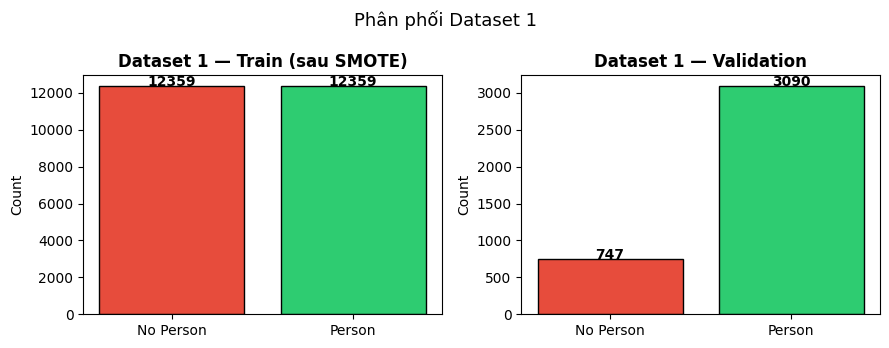

In [ ]:
print('=' * 55)
print('📥 LOAD DATASET 1')
print('=' * 55)
t0 = time.time()

X1_all, y1_all = load_features(DATASET1_POS, DATASET1_NEG, augment=True, label='Dataset 1')

# Chia train/val nội bộ 80/20
X1_tr, X1_val, y1_tr, y1_val = train_test_split(
    X1_all, y1_all, test_size=TEST_SPLIT,
    random_state=RANDOM_SEED, stratify=y1_all
)
print(f'\n⏱️  {time.time()-t0:.1f}s | Feature size: {X1_all.shape[1]}')
print(f'  Train: {X1_tr.shape[0]} | Val: {X1_val.shape[0]}')

# Balance + Scale
print('\n⚖️  Cân bằng & chuẩn hóa Dataset 1...')
X1_tr_s, y1_tr_b, scaler1 = balance_and_scale(X1_tr, y1_tr, fit_scaler=True)
X1_val_s = scaler1.transform(X1_val)

# Lưu scaler
joblib.dump(scaler1, os.path.join(CHECKPOINT_DIR, 'scaler_d1.pkl'))
print('✅ Scaler Dataset 1 đã lưu!')

# Biểu đồ phân phối
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, y_data, title in [(axes[0], y1_tr_b, 'Train (sau SMOTE)'), (axes[1], y1_val, 'Validation')]:
    counts = np.bincount(y_data)
    bars = ax.bar(['No Person','Person'], counts, color=['#e74c3c','#2ecc71'], edgecolor='black')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(c), ha='center', fontweight='bold')
    ax.set_title(f'Dataset 1 — {title}', fontweight='bold')
    ax.set_ylabel('Count')
plt.suptitle('Phân phối Dataset 1', fontsize=13)
plt.tight_layout(); plt.show()

## Bước 7a: Cross-Validation Dataset 1

⚡ Dataset 1 — LinearSVC 3-fold CV
   24718 samples | 9 lần fit tổng

┌─ [1/3] C=0.01
│   Fold 1/3 — 16478 samples... F1=0.9402 [█████████░] (70.8s)
│   Fold 2/3 — 16479 samples... F1=0.9380 [█████████░] (50.7s)
│   Fold 3/3 — 16479 samples... F1=0.9363 [█████████░] (69.1s)
└─ C=0.01 → F1=0.9382 [██████████████████░░] | Còn ~382s

┌─ [2/3] C=0.1
│   Fold 1/3 — 16478 samples... F1=0.9391 [█████████░] (119.3s)
│   Fold 2/3 — 16479 samples... F1=0.9394 [█████████░] (122.1s)
│   Fold 3/3 — 16479 samples... F1=0.9360 [█████████░] (120.7s)
└─ C=0.1 → F1=0.9382 [██████████████████░░] | Còn ~277s

┌─ [3/3] C=1.0
│   Fold 1/3 — 16478 samples... F1=0.9393 [█████████░] (112.6s)
│   Fold 2/3 — 16479 samples... F1=0.9374 [█████████░] (116.2s)
│   Fold 3/3 — 16479 samples... F1=0.9358 [█████████░] (115.5s)
└─ C=1.0 → F1=0.9375 [██████████████████░░] | Còn ~0s



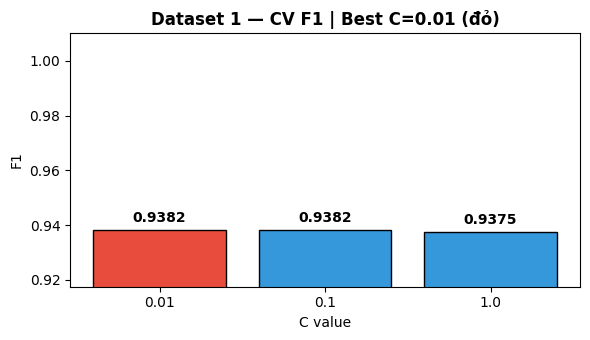

✅ Best C (Dataset 1): 0.01 — F1=0.9382


In [ ]:
from sklearn.model_selection import StratifiedKFold

C_values = [0.01, 0.1, 1.0]
cv_results_d1 = {}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
total_start = time.time()

print(f'⚡ Dataset 1 — LinearSVC 3-fold CV')
print(f'   {X1_tr_s.shape[0]} samples | {len(C_values)*3} lần fit tổng\n')

for c_idx, C in enumerate(C_values):
    fold_scores = []
    print(f'┌─ [{c_idx+1}/{len(C_values)}] C={C}')
    for fi, (tri, vali) in enumerate(skf.split(X1_tr_s, y1_tr_b)):
        fs = time.time()
        print(f'│   Fold {fi+1}/3 — {len(tri)} samples...', end=' ', flush=True)
        clf = LinearSVC(C=C, class_weight='balanced', max_iter=3000,
                        random_state=RANDOM_SEED, dual=True)
        clf.fit(X1_tr_s[tri], y1_tr_b[tri])
        f1_v = f1_score(y1_tr_b[vali], clf.predict(X1_tr_s[vali]))
        fold_scores.append(f1_v)
        bar = '█'*int(f1_v*10)+'░'*(10-int(f1_v*10))
        print(f'F1={f1_v:.4f} [{bar}] ({time.time()-fs:.1f}s)')
        del clf; gc.collect()
    mean_f1 = np.mean(fold_scores)
    cv_results_d1[C] = mean_f1
    elapsed = time.time()-total_start
    rem = (elapsed/(c_idx+1))*(len(C_values)-c_idx-1)
    bar = '█'*int(mean_f1*20)+'░'*(20-int(mean_f1*20))
    print(f'└─ C={C} → F1={mean_f1:.4f} [{bar}] | Còn ~{rem:.0f}s\n')

best_C1 = max(cv_results_d1, key=cv_results_d1.get)

# Biểu đồ CV
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ['#e74c3c' if C==best_C1 else '#3498db' for C in cv_results_d1]
bars = ax.bar([str(c) for c in cv_results_d1], list(cv_results_d1.values()),
              color=colors, edgecolor='black')
for bar, (C, score) in zip(bars, cv_results_d1.items()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{score:.4f}', ha='center', fontweight='bold')
ax.set_title(f'Dataset 1 — CV F1 | Best C={best_C1} (đỏ)', fontweight='bold')
ax.set_xlabel('C value'); ax.set_ylabel('F1')
ax.set_ylim(min(cv_results_d1.values())-0.02, 1.01)
plt.tight_layout(); plt.show()
print(f'✅ Best C (Dataset 1): {best_C1} — F1={cv_results_d1[best_C1]:.4f}')

## Bước 8a: Train Model trên Dataset 1

In [ ]:
best_score_d1 = [0.0]
best_model_d1 = None

print(f'\n📊 Train LinearSVC Dataset 1 với C={best_C1}...')
t0 = time.time()

base1 = LinearSVC(C=best_C1, class_weight='balanced',
                  max_iter=5000, random_state=RANDOM_SEED, dual=True)
model_d1 = CalibratedClassifierCV(base1, cv=3, method='sigmoid')
model_d1.fit(X1_tr_s, y1_tr_b)

train_time = time.time()-t0
y_pred_v1 = model_d1.predict(X1_val_s)
f1_v1  = f1_score(y1_val, y_pred_v1)
acc_v1 = accuracy_score(y1_val, y_pred_v1)

print(f'⏱️  Train time: {train_time:.1f}s')
print(f'📈 Val Accuracy: {acc_v1:.4f} | F1: {f1_v1:.4f}')
print(classification_report(y1_val, y_pred_v1, target_names=['No Person','Person']))

ckpt_d1 = save_checkpoint(model_d1, f1_v1, 'd1_main', best_score_d1, CHECKPOINT_DIR)
best_model_d1 = model_d1

# Hard Negative Mining Dataset 1
print('\n🔁 Hard Negative Mining Dataset 1...')
y_tr_pred1 = model_d1.predict(X1_tr_s)
hard_mask1 = ((y1_tr_b==0)&(y_tr_pred1==1)) | ((y1_tr_b==1)&(y_tr_pred1==0))
n_hard1 = np.sum(hard_mask1)
print(f'  Hard samples: {n_hard1}')

if n_hard1 > 0:
    X_hn1 = np.vstack([X1_tr_s, X1_tr_s[hard_mask1], X1_tr_s[hard_mask1]])
    y_hn1 = np.hstack([y1_tr_b, y1_tr_b[hard_mask1], y1_tr_b[hard_mask1]])
    base_hn1 = LinearSVC(C=best_C1, class_weight='balanced',
                         max_iter=5000, random_state=RANDOM_SEED, dual=True)
    model_hn1 = CalibratedClassifierCV(base_hn1, cv=3, method='sigmoid')
    model_hn1.fit(X_hn1, y_hn1)
    f1_hn1 = f1_score(y1_val, model_hn1.predict(X1_val_s))
    print(f'  F1 sau HN: {f1_hn1:.4f}')
    ckpt_hn1 = save_checkpoint(model_hn1, f1_hn1, 'd1_hardneg', best_score_d1, CHECKPOINT_DIR)
    if f1_hn1 > f1_v1:
        best_model_d1 = model_hn1
        print('  ⭐ Model HN tốt hơn!')
else:
    print('  ✅ Không có hard samples!')

# Lưu model tốt nhất Dataset 1
d1_path = os.path.join(FINAL_MODEL_DIR, 'model_dataset1_best.pkl')
joblib.dump({'model': best_model_d1, 'scaler': scaler1,
             'config': {'img_size':IMG_SIZE,'hog_orientations':HOG_ORIENTATIONS,
                        'hog_pix_per_cell':HOG_PIX_PER_CELL,'hog_cells_per_block':HOG_CELLS_PER_BLOCK,
                        'hog_block_norm':HOG_BLOCK_NORM,'best_C':best_C1,
                        'best_f1':float(best_score_d1[0]),'dataset':'dataset1'}},
            d1_path, compress=3)

# Dọn checkpoint Dataset 1
old_ckpts = glob_module.glob(os.path.join(CHECKPOINT_DIR, 'svm_d1_*.pkl'))
for o in old_ckpts: os.remove(o)
print(f'\n💾 Model Dataset 1 lưu: {d1_path}')
print(f'🗑️  Dọn {len(old_ckpts)} checkpoint Dataset 1')


📊 Train LinearSVC Dataset 1 với C=0.01...
⏱️  Train time: 213.2s
📈 Val Accuracy: 0.9004 | F1: 0.9382
              precision    recall  f1-score   support

   No Person       0.75      0.74      0.74       747
      Person       0.94      0.94      0.94      3090

    accuracy                           0.90      3837
   macro avg       0.84      0.84      0.84      3837
weighted avg       0.90      0.90      0.90      3837

  💾 Checkpoint: svm_d1_main_f10.9382.pkl
  ⭐ Best F1=0.9382

🔁 Hard Negative Mining Dataset 1...
  Hard samples: 299
  F1 sau HN: 0.9337
  💾 Checkpoint: svm_d1_hardneg_f10.9337.pkl

💾 Model Dataset 1 lưu: /content/drive/MyDrive/person_model/model_dataset1_best.pkl
🗑️  Dọn 2 checkpoint Dataset 1


## Bước 9a: Trực quan hoá kết quả Dataset 1

📊 Dataset 1 — F1=0.9382 | Acc=0.9004 | AUC=0.9338


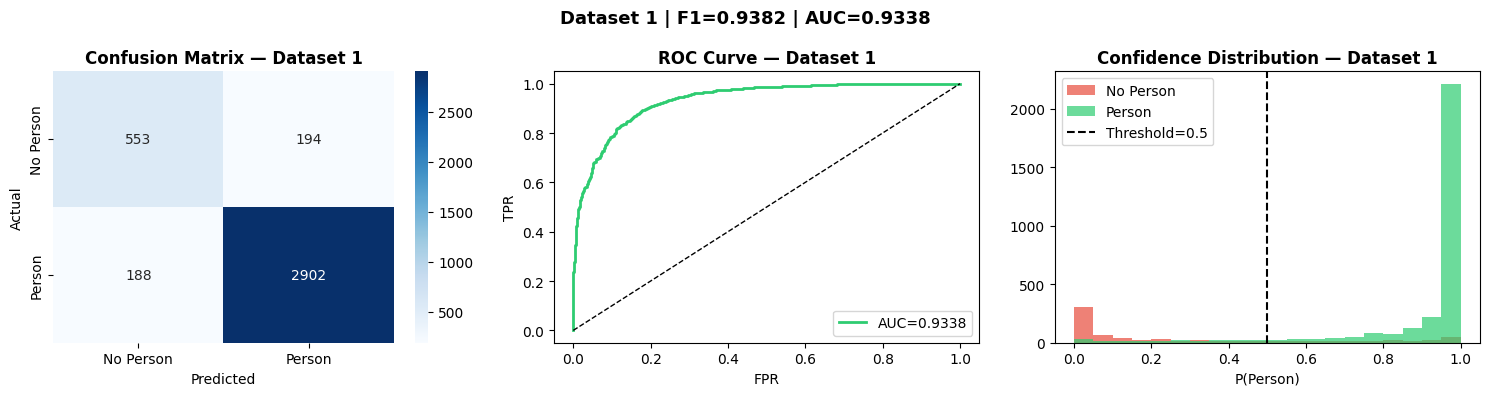

✅ Biểu đồ Dataset 1 đã lưu!


In [ ]:
y_pred_d1_final = best_model_d1.predict(X1_val_s)
y_prob_d1_final = best_model_d1.predict_proba(X1_val_s)[:,1]
f1_d1   = f1_score(y1_val, y_pred_d1_final)
acc_d1  = accuracy_score(y1_val, y_pred_d1_final)
auc_d1  = roc_auc_score(y1_val, y_prob_d1_final)

print(f'📊 Dataset 1 — F1={f1_d1:.4f} | Acc={acc_d1:.4f} | AUC={auc_d1:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm1 = confusion_matrix(y1_val, y_pred_d1_final)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Person','Person'], yticklabels=['No Person','Person'])
axes[0].set_title('Confusion Matrix — Dataset 1', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

fpr1, tpr1, _ = roc_curve(y1_val, y_prob_d1_final)
axes[1].plot(fpr1, tpr1, color='#2ecc71', lw=2, label=f'AUC={auc_d1:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curve — Dataset 1', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

axes[2].hist(y_prob_d1_final[y1_val==0], bins=20, alpha=0.7, color='#e74c3c', label='No Person')
axes[2].hist(y_prob_d1_final[y1_val==1], bins=20, alpha=0.7, color='#2ecc71', label='Person')
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[2].set_title('Confidence Distribution — Dataset 1', fontweight='bold')
axes[2].set_xlabel('P(Person)'); axes[2].legend()

plt.suptitle(f'Dataset 1 | F1={f1_d1:.4f} | AUC={auc_d1:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FINAL_MODEL_DIR,'eval_dataset1.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Biểu đồ Dataset 1 đã lưu!')

---
# 🏋️ PHẦN 2: FINE-TUNE TRÊN DATASET 2

## Bước 6b: Load Dataset 2

📥 LOAD DATASET 2
  📁 Dataset 2: 109 pos | 289 neg


    Negative: 100%|██████████| 289/289 [03:10<00:00,  1.52it/s]



⏱️  226.6s | Train: 1304 | Val: 326

⚖️  Cân bằng Dataset 2 & dùng scaler Dataset 1...
  Phân phối trước: Counter({np.int32(0): 694, np.int32(1): 610})

📊 Combined train: 26022 samples


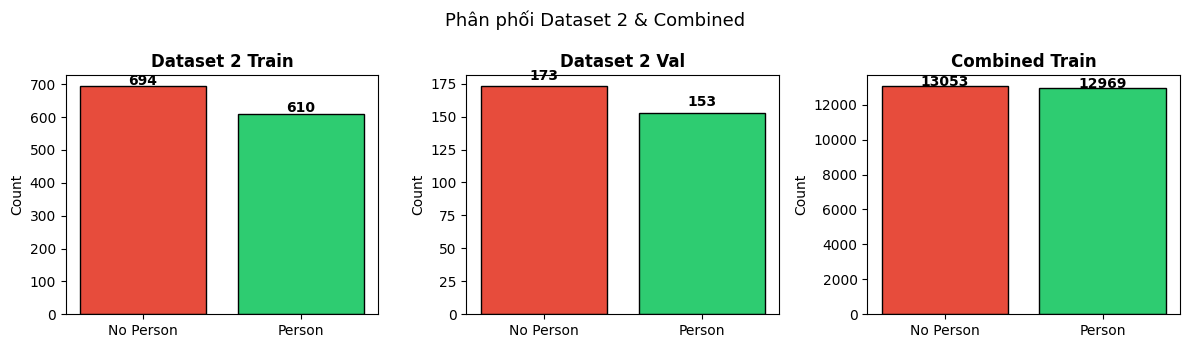

In [ ]:
print('=' * 55)
print('📥 LOAD DATASET 2')
print('=' * 55)
t0 = time.time()

X2_all, y2_all = load_features(DATASET2_POS, DATASET2_NEG, augment=True, label='Dataset 2')

X2_tr, X2_val, y2_tr, y2_val = train_test_split(
    X2_all, y2_all, test_size=TEST_SPLIT,
    random_state=RANDOM_SEED, stratify=y2_all
)
print(f'\n⏱️  {time.time()-t0:.1f}s | Train: {X2_tr.shape[0]} | Val: {X2_val.shape[0]}')

# Dùng lại scaler của Dataset 1 để không thay đổi không gian feature
print('\n⚖️  Cân bằng Dataset 2 & dùng scaler Dataset 1...')
X2_tr_s, y2_tr_b, _ = balance_and_scale(X2_tr, y2_tr, scaler=scaler1, fit_scaler=False)
X2_val_s = scaler1.transform(X2_val)

# Kết hợp Dataset 1 + Dataset 2 để fine-tune
# → Model học lại cả 2 tập để không quên Dataset 1
X_combined = np.vstack([X1_tr_s, X2_tr_s])
y_combined = np.hstack([y1_tr_b, y2_tr_b])
print(f'\n📊 Combined train: {X_combined.shape[0]} samples')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, y_data, title in [
    (axes[0], y2_tr_b,    'Dataset 2 Train'),
    (axes[1], y2_val,     'Dataset 2 Val'),
    (axes[2], y_combined, 'Combined Train'),
]:
    counts = np.bincount(y_data)
    bars = ax.bar(['No Person','Person'], counts, color=['#e74c3c','#2ecc71'], edgecolor='black')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(c), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Count')
plt.suptitle('Phân phối Dataset 2 & Combined', fontsize=13)
plt.tight_layout(); plt.show()

## Bước 7b: Cross-Validation Dataset 2 (Combined)

⚡ Dataset Combined — LinearSVC 3-fold CV
   26022 samples | 9 lần fit tổng

┌─ [1/3] C=0.01
│   Fold 1/3 — 17348 samples... F1=0.9273 [█████████░] (78.5s)
│   Fold 2/3 — 17348 samples... F1=0.9268 [█████████░] (74.2s)
│   Fold 3/3 — 17348 samples... F1=0.9279 [█████████░] (81.0s)
└─ C=0.01 → F1=0.9273 [██████████████████░░] | Còn ~468s

┌─ [2/3] C=0.1
│   Fold 1/3 — 17348 samples... F1=0.9270 [█████████░] (134.3s)
│   Fold 2/3 — 17348 samples... F1=0.9265 [█████████░] (129.4s)
│   Fold 3/3 — 17348 samples... F1=0.9301 [█████████░] (130.8s)
└─ C=0.1 → F1=0.9279 [██████████████████░░] | Còn ~315s

┌─ [3/3] C=1.0
│   Fold 1/3 — 17348 samples... F1=0.9242 [█████████░] (127.7s)
│   Fold 2/3 — 17348 samples... F1=0.9259 [█████████░] (123.6s)
│   Fold 3/3 — 17348 samples... F1=0.9274 [█████████░] (127.9s)
└─ C=1.0 → F1=0.9258 [██████████████████░░] | Còn ~0s



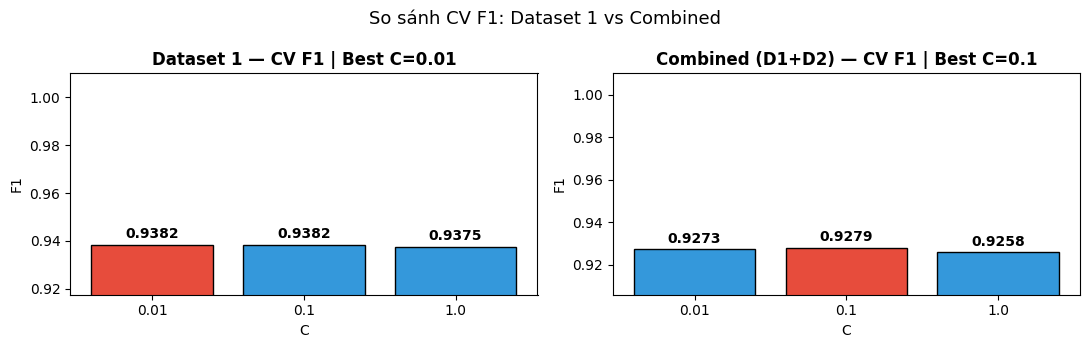

✅ Best C (Combined): 0.1 — F1=0.9279


In [ ]:
cv_results_d2 = {}
skf2 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
total_start = time.time()

print(f'⚡ Dataset Combined — LinearSVC 3-fold CV')
print(f'   {X_combined.shape[0]} samples | {len(C_values)*3} lần fit tổng\n')

for c_idx, C in enumerate(C_values):
    fold_scores = []
    print(f'┌─ [{c_idx+1}/{len(C_values)}] C={C}')
    for fi, (tri, vali) in enumerate(skf2.split(X_combined, y_combined)):
        fs = time.time()
        print(f'│   Fold {fi+1}/3 — {len(tri)} samples...', end=' ', flush=True)
        clf = LinearSVC(C=C, class_weight='balanced', max_iter=3000,
                        random_state=RANDOM_SEED, dual=True)
        clf.fit(X_combined[tri], y_combined[tri])
        f1_v = f1_score(y_combined[vali], clf.predict(X_combined[vali]))
        fold_scores.append(f1_v)
        bar = '█'*int(f1_v*10)+'░'*(10-int(f1_v*10))
        print(f'F1={f1_v:.4f} [{bar}] ({time.time()-fs:.1f}s)')
        del clf; gc.collect()
    mean_f1 = np.mean(fold_scores)
    cv_results_d2[C] = mean_f1
    elapsed = time.time()-total_start
    rem = (elapsed/(c_idx+1))*(len(C_values)-c_idx-1)
    bar = '█'*int(mean_f1*20)+'░'*(20-int(mean_f1*20))
    print(f'└─ C={C} → F1={mean_f1:.4f} [{bar}] | Còn ~{rem:.0f}s\n')

best_C2 = max(cv_results_d2, key=cv_results_d2.get)

# So sánh CV Dataset 1 vs Dataset 2
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, cv_res, best_C, title in [
    (axes[0], cv_results_d1, best_C1, 'Dataset 1'),
    (axes[1], cv_results_d2, best_C2, 'Combined (D1+D2)'),
]:
    colors = ['#e74c3c' if C==best_C else '#3498db' for C in cv_res]
    bars = ax.bar([str(c) for c in cv_res], list(cv_res.values()), color=colors, edgecolor='black')
    for bar, (C, score) in zip(bars, cv_res.items()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{score:.4f}', ha='center', fontweight='bold')
    ax.set_title(f'{title} — CV F1 | Best C={best_C}', fontweight='bold')
    ax.set_xlabel('C'); ax.set_ylabel('F1')
    ax.set_ylim(min(cv_res.values())-0.02, 1.01)
plt.suptitle('So sánh CV F1: Dataset 1 vs Combined', fontsize=13)
plt.tight_layout(); plt.show()
print(f'✅ Best C (Combined): {best_C2} — F1={cv_results_d2[best_C2]:.4f}')

## Bước 8b: Train Model trên Combined Dataset

In [ ]:
best_score_d2 = [0.0]
best_model_d2 = None

# Val kết hợp cả 2 tập
X_val_combined = np.vstack([X1_val_s, X2_val_s])
y_val_combined = np.hstack([y1_val, y2_val])

print(f'\n📊 Train LinearSVC Combined với C={best_C2}...')
t0 = time.time()

base2 = LinearSVC(C=best_C2, class_weight='balanced',
                  max_iter=5000, random_state=RANDOM_SEED, dual=True)
model_d2 = CalibratedClassifierCV(base2, cv=3, method='sigmoid')
model_d2.fit(X_combined, y_combined)

train_time = time.time()-t0
y_pred_v2 = model_d2.predict(X_val_combined)
f1_v2  = f1_score(y_val_combined, y_pred_v2)
acc_v2 = accuracy_score(y_val_combined, y_pred_v2)

print(f'⏱️  Train time: {train_time:.1f}s')
print(f'📈 Val Accuracy: {acc_v2:.4f} | F1: {f1_v2:.4f}')
print(classification_report(y_val_combined, y_pred_v2, target_names=['No Person','Person']))

ckpt_d2 = save_checkpoint(model_d2, f1_v2, 'd2_main', best_score_d2, CHECKPOINT_DIR)
best_model_d2 = model_d2

# Hard Negative Mining
print('\n🔁 Hard Negative Mining Combined...')
y_comb_pred = model_d2.predict(X_combined)
hard_mask2 = ((y_combined==0)&(y_comb_pred==1)) | ((y_combined==1)&(y_comb_pred==0))
n_hard2 = np.sum(hard_mask2)
print(f'  Hard samples: {n_hard2}')

if n_hard2 > 0:
    X_hn2 = np.vstack([X_combined, X_combined[hard_mask2], X_combined[hard_mask2]])
    y_hn2 = np.hstack([y_combined, y_combined[hard_mask2], y_combined[hard_mask2]])
    base_hn2 = LinearSVC(C=best_C2, class_weight='balanced',
                         max_iter=5000, random_state=RANDOM_SEED, dual=True)
    model_hn2 = CalibratedClassifierCV(base_hn2, cv=3, method='sigmoid')
    model_hn2.fit(X_hn2, y_hn2)
    f1_hn2 = f1_score(y_val_combined, model_hn2.predict(X_val_combined))
    print(f'  F1 sau HN: {f1_hn2:.4f}')
    ckpt_hn2 = save_checkpoint(model_hn2, f1_hn2, 'd2_hardneg', best_score_d2, CHECKPOINT_DIR)
    if f1_hn2 > f1_v2:
        best_model_d2 = model_hn2
        print('  ⭐ Model HN tốt hơn!')
else:
    print('  ✅ Không có hard samples!')

# Lưu model tốt nhất Dataset 2
d2_path = os.path.join(FINAL_MODEL_DIR, 'model_dataset2_best.pkl')
joblib.dump({'model': best_model_d2, 'scaler': scaler1,
             'config': {'img_size':IMG_SIZE,'hog_orientations':HOG_ORIENTATIONS,
                        'hog_pix_per_cell':HOG_PIX_PER_CELL,'hog_cells_per_block':HOG_CELLS_PER_BLOCK,
                        'hog_block_norm':HOG_BLOCK_NORM,'best_C':best_C2,
                        'best_f1':float(best_score_d2[0]),'dataset':'combined_d1_d2'}},
            d2_path, compress=3)

old_ckpts = glob_module.glob(os.path.join(CHECKPOINT_DIR, 'svm_d2_*.pkl'))
for o in old_ckpts: os.remove(o)
print(f'\n💾 Model Dataset 2 lưu: {d2_path}')
print(f'🗑️  Dọn {len(old_ckpts)} checkpoint Dataset 2')


📊 Train LinearSVC Combined với C=0.1...
⏱️  Train time: 626.6s
📈 Val Accuracy: 0.8837 | F1: 0.9246
              precision    recall  f1-score   support

   No Person       0.72      0.77      0.75       920
      Person       0.93      0.92      0.92      3243

    accuracy                           0.88      4163
   macro avg       0.83      0.84      0.84      4163
weighted avg       0.89      0.88      0.89      4163

  💾 Checkpoint: svm_d2_main_f10.9246.pkl
  ⭐ Best F1=0.9246

🔁 Hard Negative Mining Combined...
  Hard samples: 308
  F1 sau HN: 0.9224
  💾 Checkpoint: svm_d2_hardneg_f10.9224.pkl

💾 Model Dataset 2 lưu: /content/drive/MyDrive/person_model/model_dataset2_best.pkl
🗑️  Dọn 2 checkpoint Dataset 2


## Bước 9b: Trực quan hoá kết quả Dataset 2

📊 Combined — F1=0.9246 | Acc=0.8837 | AUC=0.9336


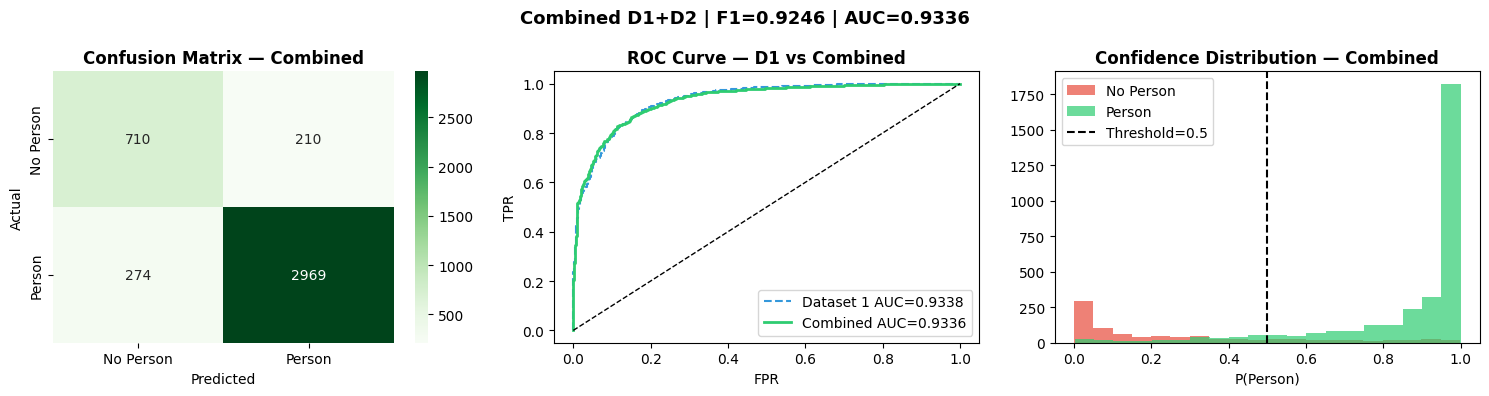

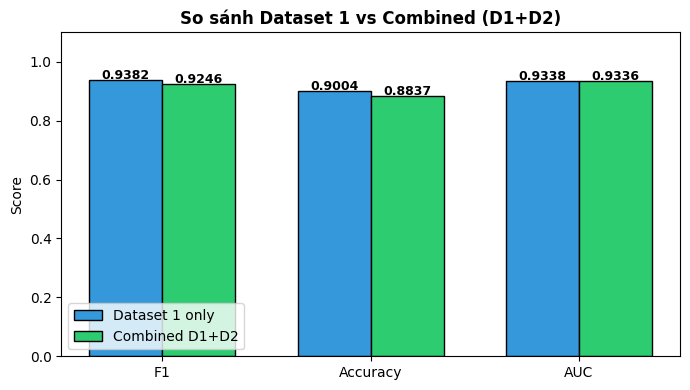

✅ Biểu đồ Combined đã lưu!


In [ ]:
y_pred_d2_final = best_model_d2.predict(X_val_combined)
y_prob_d2_final = best_model_d2.predict_proba(X_val_combined)[:,1]
f1_d2  = f1_score(y_val_combined, y_pred_d2_final)
acc_d2 = accuracy_score(y_val_combined, y_pred_d2_final)
auc_d2 = roc_auc_score(y_val_combined, y_prob_d2_final)

print(f'📊 Combined — F1={f1_d2:.4f} | Acc={acc_d2:.4f} | AUC={auc_d2:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm2 = confusion_matrix(y_val_combined, y_pred_d2_final)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Person','Person'], yticklabels=['No Person','Person'])
axes[0].set_title('Confusion Matrix — Combined', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

fpr2, tpr2, _ = roc_curve(y_val_combined, y_prob_d2_final)
axes[1].plot(fpr1, tpr1, color='#3498db', lw=1.5, linestyle='--', label=f'Dataset 1 AUC={auc_d1:.4f}')
axes[1].plot(fpr2, tpr2, color='#2ecc71', lw=2, label=f'Combined AUC={auc_d2:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curve — D1 vs Combined', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

axes[2].hist(y_prob_d2_final[y_val_combined==0], bins=20, alpha=0.7, color='#e74c3c', label='No Person')
axes[2].hist(y_prob_d2_final[y_val_combined==1], bins=20, alpha=0.7, color='#2ecc71', label='Person')
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[2].set_title('Confidence Distribution — Combined', fontweight='bold')
axes[2].set_xlabel('P(Person)'); axes[2].legend()

plt.suptitle(f'Combined D1+D2 | F1={f1_d2:.4f} | AUC={auc_d2:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FINAL_MODEL_DIR,'eval_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

# So sánh D1 vs Combined
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['F1', 'Accuracy', 'AUC']
d1_vals = [f1_d1, acc_d1, auc_d1]
d2_vals = [f1_d2, acc_d2, auc_d2]
x = np.arange(len(metrics))
w = 0.35
bars1 = ax.bar(x-w/2, d1_vals, w, label='Dataset 1 only', color='#3498db', edgecolor='black')
bars2 = ax.bar(x+w/2, d2_vals, w, label='Combined D1+D2', color='#2ecc71', edgecolor='black')
for bars, vals in [(bars1, d1_vals), (bars2, d2_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('So sánh Dataset 1 vs Combined (D1+D2)', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print('✅ Biểu đồ Combined đã lưu!')

---
# 🧪 PHẦN 3: TEST TRÊN TẬP TEST

## Bước 10: Chọn model tốt nhất & Test

⭐ Model tốt nhất: Dataset 1 only (F1=0.9382)

🧪 TEST TRÊN TẬP TEST
📁 Tìm thấy 96 ảnh trong /content/drive/MyDrive/TTNT_CK/data/PennFudan


Predicting test: 100%|██████████| 96/96 [01:10<00:00,  1.35it/s]



📊 Kết quả: 56 Person | 40 No Person / 96 ảnh


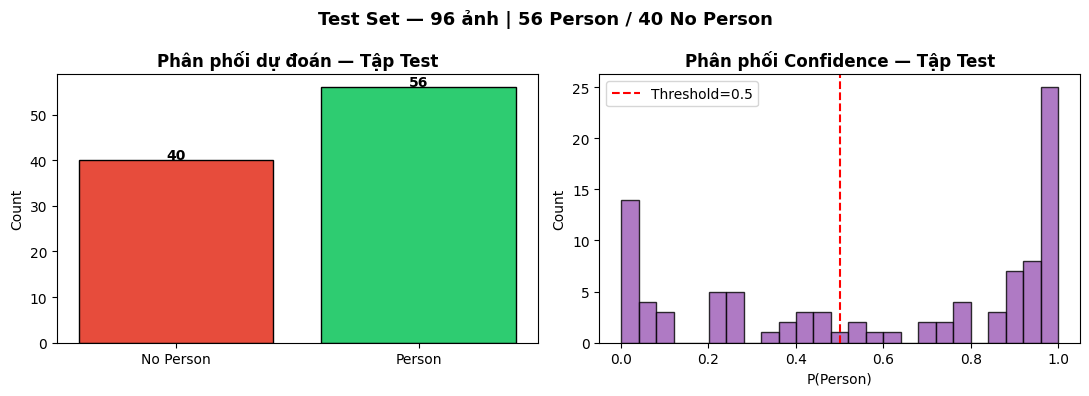

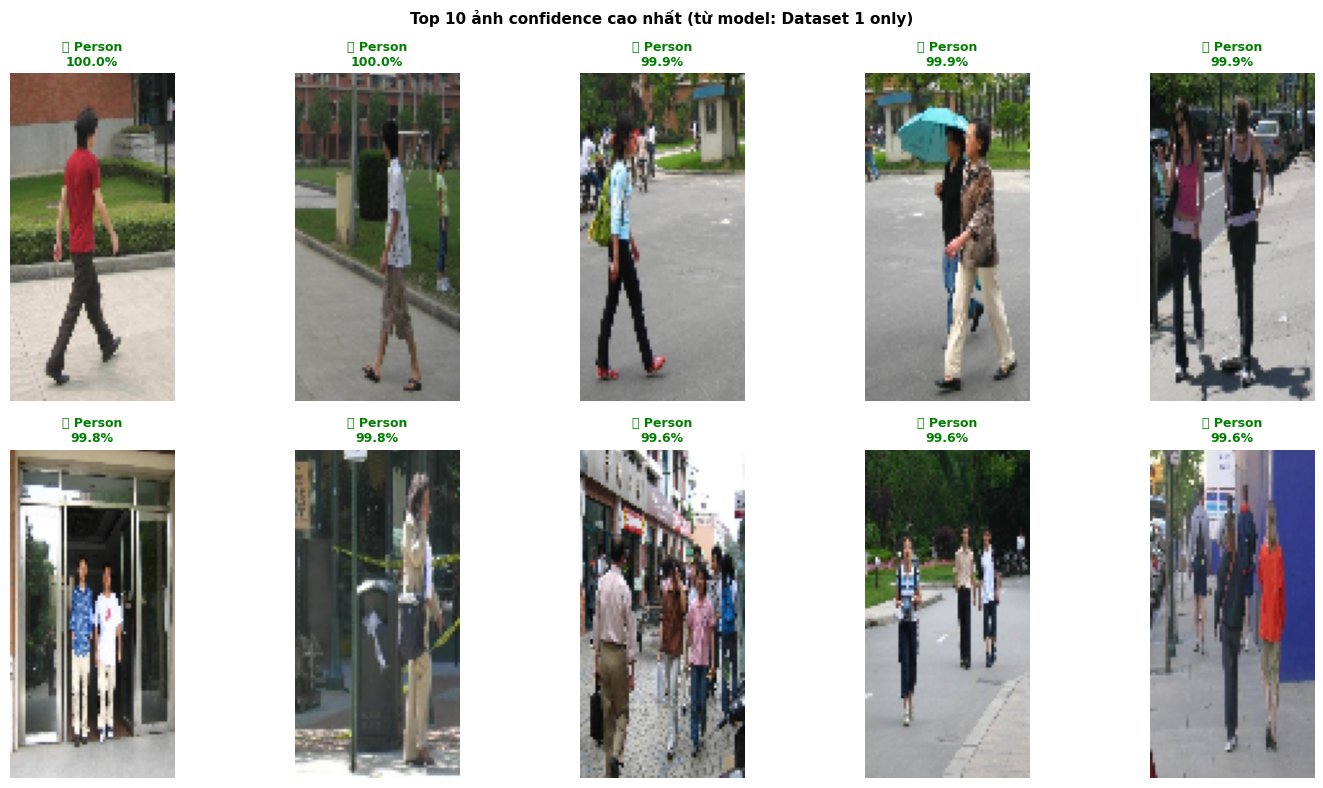

In [ ]:
import random

# Chọn model tốt nhất giữa D1 và D2
if best_score_d2[0] >= best_score_d1[0]:
    final_model = best_model_d2
    final_f1    = best_score_d2[0]
    final_from  = 'Combined D1+D2'
else:
    final_model = best_model_d1
    final_f1    = best_score_d1[0]
    final_from  = 'Dataset 1 only'

print(f'⭐ Model tốt nhất: {final_from} (F1={final_f1:.4f})')
print('\n' + '='*55)
print('🧪 TEST TRÊN TẬP TEST')
print('='*55)

test_imgs = []
for ext in IMG_EXTS:
    test_imgs += glob_module.glob(os.path.join(TEST_DIR, ext))
print(f'📁 Tìm thấy {len(test_imgs)} ảnh trong {TEST_DIR}')

if len(test_imgs) == 0:
    print('⚠️  Không có ảnh trong TEST_DIR!')
else:
    results = []
    for path in tqdm(test_imgs, desc='Predicting test'):
        img = cv2.imread(path)
        if img is None: continue
        proc = preprocess_image(img)
        feat = extract_hog_features(proc)
        feat_s = scaler1.transform(feat.reshape(1,-1))
        label = final_model.predict(feat_s)[0]
        prob  = final_model.predict_proba(feat_s)[0][1]
        results.append((path, label, prob))

    n_person   = sum(1 for _,l,_ in results if l==1)
    n_noperson = sum(1 for _,l,_ in results if l==0)
    print(f'\n📊 Kết quả: {n_person} Person | {n_noperson} No Person / {len(results)} ảnh')

    # Biểu đồ phân phối kết quả test
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].bar(['No Person','Person'], [n_noperson, n_person],
               color=['#e74c3c','#2ecc71'], edgecolor='black')
    axes[0].set_title('Phân phối dự đoán — Tập Test', fontweight='bold')
    axes[0].set_ylabel('Count')
    for i, v in enumerate([n_noperson, n_person]):
        axes[0].text(i, v+0.3, str(v), ha='center', fontweight='bold')

    probs = [p for _,_,p in results]
    axes[1].hist(probs, bins=25, color='#9b59b6', edgecolor='black', alpha=0.8)
    axes[1].axvline(0.5, color='red', linestyle='--', label='Threshold=0.5')
    axes[1].set_title('Phân phối Confidence — Tập Test', fontweight='bold')
    axes[1].set_xlabel('P(Person)'); axes[1].set_ylabel('Count')
    axes[1].legend()

    plt.suptitle(f'Test Set — {len(results)} ảnh | {n_person} Person / {n_noperson} No Person',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Visual check top 10 confidence cao nhất
    results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
    sample = results_sorted[:10]
    cols = 5
    rows = (len(sample)+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*4))
    ax_flat = axes.flatten() if rows>1 else [axes] if cols==1 else axes
    for i, ax in enumerate(ax_flat):
        if i < len(sample):
            path, label, prob = sample[i]
            img = cv2.imread(path)
            img = cv2.cvtColor(cv2.resize(img,(64,128)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            color = 'green' if label==1 else 'red'
            ax.set_title(f'{"✅ Person" if label==1 else "❌ No Person"}\n{prob:.1%}',
                         color=color, fontsize=9, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f'Top {len(sample)} ảnh confidence cao nhất (từ model: {final_from})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

## Bước 11: Lưu model cuối & Export

In [ ]:
pipeline_final = {
    'model':  final_model,
    'scaler': scaler1,
    'config': {
        'img_size':            IMG_SIZE,
        'hog_orientations':    HOG_ORIENTATIONS,
        'hog_pix_per_cell':    HOG_PIX_PER_CELL,
        'hog_cells_per_block': HOG_CELLS_PER_BLOCK,
        'hog_block_norm':      HOG_BLOCK_NORM,
        'best_C':              best_C2 if final_from != 'Dataset 1 only' else best_C1,
        'best_f1':             float(final_f1),
        'feature_size':        int(X1_all.shape[1]),
        'trained_on':          final_from,
    }
}

final_path = os.path.join(FINAL_MODEL_DIR, 'person_detector_pipeline.pkl')
joblib.dump(pipeline_final, final_path, compress=3)
size_mb = os.path.getsize(final_path)/1024/1024

config_path = os.path.join(FINAL_MODEL_DIR, 'model_config.json')
json.dump(pipeline_final['config'], open(config_path,'w'), indent=2)

# Dọn toàn bộ checkpoint còn lại
old_all = glob_module.glob(os.path.join(CHECKPOINT_DIR, 'svm_*.pkl'))
for o in old_all: os.remove(o)

print('🎉 HOÀN THÀNH!')
print(f'\n⭐ Model tốt nhất: {final_from}')
print(f'   F1={final_f1:.4f}')
print(f'\n📦 Download file này về máy:')
print(f'   {final_path} ({size_mb:.2f} MB)')
print(f'\n📊 So sánh:')
print(f'   Dataset 1 only  → F1={best_score_d1[0]:.4f}')
print(f'   Combined D1+D2  → F1={best_score_d2[0]:.4f}')
print(f'   → Dùng: {final_from}')
print(f'\n🗑️  Dọn {len(old_all)} checkpoint trung gian')

🎉 HOÀN THÀNH!

⭐ Model tốt nhất: Dataset 1 only
   F1=0.9382

📦 Download file này về máy:
   /content/drive/MyDrive/person_model/person_detector_pipeline.pkl (0.17 MB)

📊 So sánh:
   Dataset 1 only  → F1=0.9382
   Combined D1+D2  → F1=0.9246
   → Dùng: Dataset 1 only

🗑️  Dọn 0 checkpoint trung gian


---
## 🔄 RESUME — Chạy nếu bị ngắt giữa chừng

In [ ]:
import os, glob as glob_module, joblib

# Kiểm tra model cuối
final_path = os.path.join(FINAL_MODEL_DIR, 'person_detector_pipeline.pkl')
d1_path    = os.path.join(FINAL_MODEL_DIR, 'model_dataset1_best.pkl')
d2_path    = os.path.join(FINAL_MODEL_DIR, 'model_dataset2_best.pkl')

if os.path.exists(final_path):
    print('✅ Model CUỐI đã có! Không cần train lại.')
    p = joblib.load(final_path)
    print(f"   Config: {p['config']}")

elif os.path.exists(d2_path):
    print('🔄 Có model Dataset 2. Chỉ cần chạy Bước 10 (Test) và Bước 11 (Export).')
    p2 = joblib.load(d2_path)
    best_model_d2 = p2['model']
    scaler1       = p2['scaler']
    best_score_d2 = [p2['config']['best_f1']]
    print(f"   F1 D2: {best_score_d2[0]:.4f}")

elif os.path.exists(d1_path):
    print('🔄 Có model Dataset 1. Chạy lại từ Bước 6b (Load Dataset 2).')
    p1 = joblib.load(d1_path)
    best_model_d1 = p1['model']
    scaler1       = p1['scaler']
    best_score_d1 = [p1['config']['best_f1']]
    print(f"   F1 D1: {best_score_d1[0]:.4f}")

else:
    ckpts = sorted(glob_module.glob(os.path.join(CHECKPOINT_DIR, 'svm_*.pkl')))
    if ckpts:
        latest = ckpts[-1]
        stage = 'd1' if 'd1' in latest else 'd2'
        print(f'🔄 Checkpoint: {os.path.basename(latest)} (stage={stage})')
        if stage == 'd1':
            best_model_d1 = joblib.load(latest)
            scaler1       = joblib.load(os.path.join(CHECKPOINT_DIR,'scaler_d1.pkl'))
            print('   → Chạy tiếp Bước 9a (Visualise D1) hoặc Bước 6b (Load D2)')
        else:
            best_model_d2 = joblib.load(latest)
            scaler1       = joblib.load(os.path.join(CHECKPOINT_DIR,'scaler_d1.pkl'))
            print('   → Chạy tiếp Bước 9b (Visualise Combined) hoặc Bước 10 (Test)')
    else:
        print('❌ Không có checkpoint. Chạy lại từ Bước 6a.')